In [1]:
# Cell 1: Setup and frozen protocol
import gc
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

try:
    import psutil
except ImportError:
    psutil = None


def find_project_root():
    """Locate the repository root."""
    for candidate in (Path.cwd(), *Path.cwd().parents):
        if (candidate / "phase1" / "src").is_dir():
            return candidate
    raise FileNotFoundError("Cannot locate the project root.")


PROJECT_ROOT = find_project_root()
PHASE_DIR = PROJECT_ROOT / "phase1"
SOURCE_DIR = PHASE_DIR / "src"
DATA_DIR = PHASE_DIR / "segmentated_data" / "dhdata"
RESULTS_DIR = PHASE_DIR / "results" / "rqa"
INDEX_PATH = DATA_DIR / "segments_index.csv"

if str(SOURCE_DIR) not in sys.path:
    sys.path.insert(0, str(SOURCE_DIR))

from dataloader.loader import load_segmented_session
from rqa.rqa import run_rqa

M = 8
TAU_SECONDS = {"Processed": 0.16, "Raw": 0.20}
TARGET_RR = 0.02
L_MIN = 2
V_MIN = 2
RR_TOLERANCE = 5e-5
WINDOW_SIZES = (60, 120, 180)
REPRESENTATIONS = ("Processed", "Raw")
STATES = ("Awake", "Drowsy")
STATE_LABELS = {0: "Awake", 1: "Drowsy"}
METRICS = ("DET", "Lmean", "ENTR", "Lmax", "LAM", "TT", "Vmax")

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
WINDOW_OUTPUT = RESULTS_DIR / "rqa_window_level.csv"
QC_OUTPUT = RESULTS_DIR / "rqa_qc_summary.csv"
SESSION_OUTPUT = RESULTS_DIR / "rqa_session_state_summary.csv"
DELTA_OUTPUT = RESULTS_DIR / "rqa_session_paired_deltas.csv"
RQ2_OUTPUT = RESULTS_DIR / "rqa_rq2_summary.csv"

protocol = pd.DataFrame(
    {
        "parameter": [
            "Embedding dimension",
            "Processed tau",
            "Raw tau",
            "Theiler rule",
            "Distance",
            "Target RR",
            "Minimum diagonal line",
            "Minimum vertical line",
            "Processed eligibility",
            "Raw eligibility",
        ],
        "value": [
            M,
            f"{TAU_SECONDS['Processed']:.2f} s",
            f"{TAU_SECONDS['Raw']:.2f} s",
            "(m - 1) * tau_samples",
            "Euclidean",
            TARGET_RR,
            L_MIN,
            V_MIN,
            "SQI + Processed stationarity",
            "SQI only; stationarity disabled",
        ],
    }
)

session_files = sorted(DATA_DIR.glob("*.npz"))
print(f"Sessions found: {len(session_files)}")
display(protocol)


Sessions found: 20


,parameter,value
0,Embedding dimension,8
1,Processed tau,0.16 s
2,Raw tau,0.20 s
3,Theiler rule,(m - 1) * tau_samples
4,Distance,Euclidean
5,Target RR,0.02
6,Minimum diagonal line,2
7,Minimum vertical line,2
8,Processed eligibility,SQI + Processed stationarity
9,Raw eligibility,SQI only; stationarity disabled


In [2]:
# Cell 2: Coverage and paired availability
segment_index = pd.read_csv(INDEX_PATH)

for column in (
    "stationarity_pass_raw",
    "stationarity_pass_processed",
):
    if segment_index[column].dtype != bool:
        segment_index[column] = (
            segment_index[column]
            .astype(str)
            .str.strip()
            .str.lower()
            .map({"true": True, "false": False})
        )
    if segment_index[column].isna().any():
        raise ValueError(f"Invalid boolean values in {column}.")

segment_index["session"] = segment_index["npz_file"].map(
    lambda value: Path(value).stem
)
segment_index["state"] = segment_index["label"].map(STATE_LABELS)

raw_index = segment_index.assign(representation="Raw")
processed_index = segment_index.loc[
    segment_index["stationarity_pass_processed"]
].assign(representation="Processed")
eligible_index = pd.concat(
    [processed_index, raw_index],
    ignore_index=True,
)

coverage_columns = [
    "session",
    "representation",
    "state",
    "window_size_s",
]
coverage = (
    eligible_index.groupby(coverage_columns, observed=True)
    .size()
    .rename("n_windows")
)
expected_index = pd.MultiIndex.from_product(
    [
        sorted(segment_index["session"].unique()),
        REPRESENTATIONS,
        STATES,
        WINDOW_SIZES,
    ],
    names=coverage_columns,
)
coverage = (
    coverage.reindex(expected_index, fill_value=0)
    .reset_index()
    .sort_values(coverage_columns)
    .reset_index(drop=True)
)

paired = coverage.pivot_table(
    index=["session", "representation", "window_size_s"],
    columns="state",
    values="n_windows",
    fill_value=0,
)
paired["paired"] = (paired["Awake"] > 0) & (paired["Drowsy"] > 0)
paired_sessions = (
    paired.reset_index()
    .groupby(["representation", "window_size_s"], observed=True)["paired"]
    .sum()
    .rename("n_paired_sessions")
    .reset_index()
)

display(coverage)
display(paired_sessions)

missing_coverage = coverage.loc[coverage["n_windows"] == 0]
if not missing_coverage.empty:
    display(missing_coverage)
    raise RuntimeError("Coverage check failed; inspect missing groups.")

print("Coverage check: PASS")


,session,representation,state,window_size_s,n_windows
0,sample_1,Processed,Awake,60,24
1,sample_1,Processed,Awake,120,11
2,sample_1,Processed,Awake,180,6
3,sample_1,Processed,Drowsy,60,7
4,sample_1,Processed,Drowsy,120,1
...,...,...,...,...,...
235,sample_9,Raw,Awake,120,22
236,sample_9,Raw,Awake,180,13
237,sample_9,Raw,Drowsy,60,21
238,sample_9,Raw,Drowsy,120,10


,representation,window_size_s,n_paired_sessions
0,Processed,60,20
1,Processed,120,20
2,Processed,180,20
3,Raw,60,20
4,Raw,120,20
5,Raw,180,20


Coverage check: PASS


In [3]:
# Cell 3: Full window-level RQA
WINDOW_COLUMNS = [
    "session",
    "representation",
    "state",
    "window_size",
    "window_id",
    "fs",
    "tau_samples",
    "theiler_samples",
    "epsilon",
    "target_rr",
    "achieved_rr",
    *METRICS,
    "n_diagonal_lines",
    "n_vertical_lines",
]
KEY_COLUMNS = [
    "session",
    "representation",
    "state",
    "window_size",
    "window_id",
]
CHECKPOINT_EVERY = 10


def estimate_peak_gib(n_samples, tau_samples):
    """Estimate conservative peak memory for one RQA window."""
    n_vectors = n_samples - (M - 1) * tau_samples
    return 28 * n_vectors**2 / 1024**3


def validate_checkpoint(frame, expected_keys):
    """Validate a resumable window-level checkpoint."""
    missing = set(WINDOW_COLUMNS).difference(frame.columns)
    if missing:
        raise ValueError(f"Checkpoint columns missing: {sorted(missing)}")
    if frame.duplicated(KEY_COLUMNS).any():
        raise ValueError("Checkpoint contains duplicate window keys.")

    keys = set(frame[KEY_COLUMNS].itertuples(index=False, name=None))
    if not keys.issubset(expected_keys):
        raise ValueError("Checkpoint contains unexpected window keys.")
    if not set(frame["representation"]).issubset(REPRESENTATIONS):
        raise ValueError("Checkpoint contains an invalid representation.")
    if not np.allclose(frame["target_rr"], TARGET_RR):
        raise ValueError("Checkpoint uses a different target RR.")
    expected_tau = np.rint(
        frame["fs"] * frame["representation"].map(TAU_SECONDS)
    ).astype(int)
    if not np.array_equal(frame["tau_samples"], expected_tau):
        raise ValueError("Checkpoint uses a different embedding delay.")
    expected_theiler = (M - 1) * expected_tau
    if not np.array_equal(frame["theiler_samples"], expected_theiler):
        raise ValueError("Checkpoint uses a different Theiler window.")


def append_records(records, output_path):
    """Append scalar RQA records to the master output."""
    if not records:
        return
    frame = pd.DataFrame.from_records(records, columns=WINDOW_COLUMNS)
    frame.to_csv(
        output_path,
        mode="a",
        header=not output_path.exists(),
        index=False,
    )
    records.clear()


expected_rows = eligible_index.loc[
    :,
    [
        "session",
        "representation",
        "state",
        "window_size_s",
        "window_id",
    ],
].rename(columns={"window_size_s": "window_size"})
if expected_rows.duplicated(KEY_COLUMNS).any():
    raise ValueError("Eligible metadata contains duplicate window keys.")
expected_keys = set(
    expected_rows[KEY_COLUMNS].itertuples(index=False, name=None)
)

if WINDOW_OUTPUT.exists():
    checkpoint = pd.read_csv(WINDOW_OUTPUT)
    validate_checkpoint(checkpoint, expected_keys)
    completed_keys = set(
        checkpoint[KEY_COLUMNS].itertuples(index=False, name=None)
    )
else:
    checkpoint = pd.DataFrame(columns=WINDOW_COLUMNS)
    completed_keys = set()

tasks = (
    eligible_index[
        ["session", "representation", "window_size_s"]
    ]
    .drop_duplicates()
    .sort_values(["session", "representation", "window_size_s"])
    .itertuples(index=False, name=None)
)
tasks = list(tasks)
records = []

print(f"Expected windows: {len(expected_keys)}")
print(f"Windows already complete: {len(completed_keys)}")

for task_number, (session, representation, window_size) in enumerate(
    tasks,
    start=1,
):
    stationarity_only = representation == "Processed"
    batches, _ = load_segmented_session(
        session=session,
        data_dir=DATA_DIR,
        window_sizes=(int(window_size),),
        representation=representation.lower(),
        stationarity_only=stationarity_only,
    )
    batch = batches[int(window_size)]
    tau_samples = int(round(TAU_SECONDS[representation] * batch["fs"]))
    peak_gib = estimate_peak_gib(batch["n_samples"], tau_samples)

    if psutil is not None:
        available_gib = psutil.virtual_memory().available / 1024**3
        if available_gib < 1.25 * peak_gib:
            raise MemoryError(
                "Insufficient free RAM for the next RQA window: "
                f"{available_gib:.2f} GiB available, "
                f"{peak_gib:.2f} GiB estimated peak."
            )

    for array_index, window_id in enumerate(batch["window_id"]):
        state = STATE_LABELS[int(batch["label"][array_index])]
        key = (
            session,
            representation,
            state,
            int(window_size),
            int(window_id),
        )
        if key in completed_keys:
            continue

        signal = batch["signal"][array_index]
        result = run_rqa(
            signal,
            m=M,
            tau=tau_samples,
            l_min=L_MIN,
            v_min=V_MIN,
            target_rr=TARGET_RR,
        )
        records.append(
            {
                "session": session,
                "representation": representation,
                "state": state,
                "window_size": int(window_size),
                "window_id": int(window_id),
                "fs": float(batch["fs"]),
                "tau_samples": tau_samples,
                "theiler_samples": result.theiler,
                "epsilon": result.epsilon,
                "target_rr": result.target_rr,
                "achieved_rr": result.achieved_rr,
                "DET": result.det,
                "Lmean": result.l_mean,
                "ENTR": result.entr,
                "Lmax": result.l_max,
                "LAM": result.lam,
                "TT": result.tt,
                "Vmax": result.v_max,
                "n_diagonal_lines": result.n_diagonal_lines,
                "n_vertical_lines": result.n_vertical_lines,
            }
        )
        completed_keys.add(key)
        del signal, result

        if len(records) >= CHECKPOINT_EVERY:
            append_records(records, WINDOW_OUTPUT)

    append_records(records, WINDOW_OUTPUT)
    del batches, batch
    gc.collect()
    print(
        f"Task {task_number}/{len(tasks)} complete: "
        f"{session}, {representation}, {window_size} s; "
        f"estimated peak {peak_gib:.2f} GiB"
    )

window_results = pd.read_csv(WINDOW_OUTPUT)
validate_checkpoint(window_results, expected_keys)
actual_keys = set(
    window_results[KEY_COLUMNS].itertuples(index=False, name=None)
)
if actual_keys != expected_keys:
    raise RuntimeError("Window-level RQA output is incomplete.")

window_results = window_results.sort_values(KEY_COLUMNS).reset_index(drop=True)
window_results.to_csv(WINDOW_OUTPUT, index=False)
display(window_results.head())
print(f"Window-level rows saved: {len(window_results)}")


Expected windows: 3181
Windows already complete: 3181
Task 1/120 complete: sample_1, Processed, 60 s; estimated peak 0.23 GiB
Task 2/120 complete: sample_1, Processed, 120 s; estimated peak 0.92 GiB


Task 3/120 complete: sample_1, Processed, 180 s; estimated peak 2.09 GiB
Task 4/120 complete: sample_1, Raw, 60 s; estimated peak 0.22 GiB


Task 5/120 complete: sample_1, Raw, 120 s; estimated peak 0.92 GiB


Task 6/120 complete: sample_1, Raw, 180 s; estimated peak 2.08 GiB
Task 7/120 complete: sample_10, Processed, 60 s; estimated peak 0.06 GiB
Task 8/120 complete: sample_10, Processed, 120 s; estimated peak 0.23 GiB


Task 9/120 complete: sample_10, Processed, 180 s; estimated peak 0.52 GiB
Task 10/120 complete: sample_10, Raw, 60 s; estimated peak 0.06 GiB
Task 11/120 complete: sample_10, Raw, 120 s; estimated peak 0.23 GiB


...

Task 113/120 complete: sample_8, Raw, 120 s; estimated peak 0.23 GiB
Task 114/120 complete: sample_8, Raw, 180 s; estimated peak 0.52 GiB
Task 115/120 complete: sample_9, Processed, 60 s; estimated peak 0.06 GiB


Task 116/120 complete: sample_9, Processed, 120 s; estimated peak 0.23 GiB
Task 117/120 complete: sample_9, Processed, 180 s; estimated peak 0.52 GiB
Task 118/120 complete: sample_9, Raw, 60 s; estimated peak 0.06 GiB


Task 119/120 complete: sample_9, Raw, 120 s; estimated peak 0.23 GiB
Task 120/120 complete: sample_9, Raw, 180 s; estimated peak 0.52 GiB


,session,representation,state,window_size,window_id,fs,tau_samples,theiler_samples,epsilon,target_rr,achieved_rr,DET,Lmean,ENTR,Lmax,LAM,TT,Vmax,n_diagonal_lines,n_vertical_lines
0,sample_1,Processed,Awake,60,1,50.0,8,56,117.450855,0.02,0.02,0.904122,4.727985,1.935400,132,0.644140,2.389823,5,15944,44946
1,sample_1,Processed,Awake,60,2,50.0,8,56,109.782483,0.02,0.02,0.913465,4.812765,1.942604,164,0.705069,2.467688,5,15825,47645
2,sample_1,Processed,Awake,60,3,50.0,8,56,114.637603,0.02,0.02,0.911378,4.610083,1.914764,149,0.713956,2.482122,5,16483,47965
3,sample_1,Processed,Awake,60,4,50.0,8,56,101.614095,0.02,0.02,0.929393,5.266055,2.047586,161,0.560113,2.272143,5,14715,41107
4,sample_1,Processed,Awake,60,5,50.0,8,56,108.734577,0.02,0.02,0.915672,4.775206,1.917850,168,0.638258,2.351673,5,15988,45258


Window-level rows saved: 3181


In [4]:
# Cell 4: Full-dataset quality control
window_results = pd.read_csv(WINDOW_OUTPUT)
numeric_columns = [
    "fs",
    "tau_samples",
    "theiler_samples",
    "epsilon",
    "target_rr",
    "achieved_rr",
    *METRICS,
    "n_diagonal_lines",
    "n_vertical_lines",
]
numeric_values = window_results[numeric_columns].to_numpy(dtype=float)

quality = window_results[
    ["representation", "window_size"]
].copy()
quality["invalid_output"] = ~np.isfinite(numeric_values).all(axis=1)
quality["rr_error"] = (
    window_results["achieved_rr"] - TARGET_RR
).abs()
quality["zero_diagonal_support"] = (
    window_results["n_diagonal_lines"] == 0
)
quality["zero_vertical_support"] = (
    window_results["n_vertical_lines"] == 0
)
quality["invalid_det_lam"] = (
    ~window_results["DET"].between(0.0, 1.0)
    | ~window_results["LAM"].between(0.0, 1.0)
)
quality["invalid_metric"] = (
    (window_results[["Lmean", "ENTR", "Lmax", "TT", "Vmax"]] < 0)
    .any(axis=1)
    | (window_results["epsilon"] <= 0)
    | ~window_results["achieved_rr"].between(0.0, 1.0)
    | (window_results["n_diagonal_lines"] < 0)
    | (window_results["n_vertical_lines"] < 0)
)
quality["lmax_below_lmean"] = (
    window_results["Lmax"] < window_results["Lmean"]
)
quality["vmax_below_tt"] = (
    window_results["Vmax"] < window_results["TT"]
)

qc_summary = (
    quality.groupby(
        ["representation", "window_size"],
        observed=True,
    )
    .agg(
        n_windows=("invalid_output", "size"),
        invalid_outputs=("invalid_output", "sum"),
        max_rr_error=("rr_error", "max"),
        zero_diagonal_support=("zero_diagonal_support", "sum"),
        zero_vertical_support=("zero_vertical_support", "sum"),
        invalid_det_lam=("invalid_det_lam", "sum"),
        invalid_metrics=("invalid_metric", "sum"),
        lmax_below_lmean=("lmax_below_lmean", "sum"),
        vmax_below_tt=("vmax_below_tt", "sum"),
    )
    .reset_index()
)
qc_summary.to_csv(QC_OUTPUT, index=False)
display(qc_summary)

qc_pass = (
    qc_summary["invalid_outputs"].sum() == 0
    and qc_summary["max_rr_error"].max() <= RR_TOLERANCE
    and qc_summary["zero_diagonal_support"].sum() == 0
    and qc_summary["zero_vertical_support"].sum() == 0
    and qc_summary["invalid_det_lam"].sum() == 0
    and qc_summary["invalid_metrics"].sum() == 0
    and qc_summary["lmax_below_lmean"].sum() == 0
    and qc_summary["vmax_below_tt"].sum() == 0
)
print(f"Full-dataset QC: {'PASS' if qc_pass else 'FAIL'}")

if not qc_pass:
    raise RuntimeError("Full-dataset QC failed; stop before aggregation.")


,representation,window_size,n_windows,invalid_outputs,max_rr_error,zero_diagonal_support,zero_vertical_support,invalid_det_lam,invalid_metrics,lmax_below_lmean,vmax_below_tt
0,Processed,60,901,0,9.034960e-07,0,0,0,0,0,0
1,Processed,120,405,0,2.171325e-07,0,0,0,0,0,0
2,Processed,180,238,0,9.525833e-08,0,0,0,0,0,0
3,Raw,60,951,0,3.229800e-06,0,0,0,0,0,0
4,Raw,120,432,0,7.690542e-07,0,0,0,0,0,0
5,Raw,180,254,0,3.363834e-07,0,0,0,0,0,0


Full-dataset QC: PASS


In [5]:
# Cell 5: Session-level aggregation
aggregation = {}
for metric in METRICS:
    aggregation[f"{metric}_mean"] = (metric, "mean")
    aggregation[f"{metric}_std"] = (metric, "std")
    aggregation[f"{metric}_median"] = (metric, "median")

session_summary = (
    window_results.groupby(
        ["session", "representation", "state", "window_size"],
        observed=True,
    )
    .agg(
        n_windows=("window_id", "size"),
        **aggregation,
    )
    .reset_index()
    .sort_values(
        ["session", "representation", "state", "window_size"]
    )
    .reset_index(drop=True)
)
session_summary.to_csv(SESSION_OUTPUT, index=False)
display(session_summary.head(12))
print(f"Session-state rows saved: {len(session_summary)}")


,session,representation,state,window_size,n_windows,DET_mean,DET_std,DET_median,Lmean_mean,Lmean_std,...,Lmax_median,LAM_mean,LAM_std,LAM_median,TT_mean,TT_std,TT_median,Vmax_mean,Vmax_std,Vmax_median
0,sample_1,Processed,Awake,60,24,0.918084,0.012299,0.919174,4.966876,0.329073,...,174.0,0.735153,0.091974,0.725728,2.509224,0.220576,2.459658,6.041667,1.458980,5.5
1,sample_1,Processed,Awake,120,11,0.918575,0.010609,0.919850,4.985234,0.291687,...,244.0,0.759895,0.073615,0.783228,2.520243,0.117312,2.569770,7.000000,1.897367,7.0
2,sample_1,Processed,Awake,180,6,0.917676,0.010463,0.914929,4.973382,0.311559,...,243.0,0.754826,0.058492,0.749737,2.500680,0.068003,2.507126,6.666667,1.632993,6.5
3,sample_1,Processed,Drowsy,60,7,0.931293,0.014919,0.939096,5.256252,0.353057,...,204.0,0.802732,0.043888,0.791435,2.527758,0.152916,2.448311,7.428571,2.636737,7.0
4,sample_1,Processed,Drowsy,120,1,0.935083,NaN,0.935083,5.367463,NaN,...,264.0,0.817028,NaN,0.817028,2.503560,NaN,2.503560,11.000000,NaN,11.0
5,sample_1,Processed,Drowsy,180,1,0.936743,NaN,0.936743,5.356364,NaN,...,264.0,0.807938,NaN,0.807938,2.478091,NaN,2.478091,11.000000,NaN,11.0
6,sample_1,Raw,Awake,60,24,0.952835,0.016289,0.949780,5.431057,0.935633,...,190.5,0.975446,0.011095,0.975214,5.105385,0.971253,4.799231,18.875000,15.962762,12.5
7,sample_1,Raw,Awake,120,11,0.956167,0.015222,0.948174,5.488960,0.749784,...,240.0,0.979468,0.008898,0.976994,5.386829,0.888116,5.185907,35.272727,26.608611,22.0
8,sample_1,Raw,Awake,180,6,0.957421,0.016227,0.956498,5.514059,0.879399,...,293.5,0.981262,0.008589,0.981561,5.586561,0.878337,5.578976,32.333333,23.491843,21.5
9,sample_1,Raw,Drowsy,60,10,0.971449,0.009148,0.969861,7.351509,1.999075,...,241.5,0.986043,0.004377,0.985218,6.335171,2.016957,5.521265,52.300000,61.573894,23.0


Session-state rows saved: 240


In [6]:
# Cell 6: Paired Awake-Drowsy contrasts
group_columns = ["session", "representation", "window_size"]
mean_columns = [f"{metric}_mean" for metric in METRICS]

awake = session_summary.loc[
    session_summary["state"] == "Awake",
    [*group_columns, "n_windows", *mean_columns],
].rename(
    columns={
        "n_windows": "n_awake_windows",
        **{
            column: f"{column}_awake"
            for column in mean_columns
        },
    }
)
drowsy = session_summary.loc[
    session_summary["state"] == "Drowsy",
    [*group_columns, "n_windows", *mean_columns],
].rename(
    columns={
        "n_windows": "n_drowsy_windows",
        **{
            column: f"{column}_drowsy"
            for column in mean_columns
        },
    }
)

paired_deltas = awake.merge(
    drowsy,
    on=group_columns,
    how="inner",
    validate="one_to_one",
)
for metric in METRICS:
    paired_deltas[f"delta_{metric}"] = (
        paired_deltas[f"{metric}_mean_drowsy"]
        - paired_deltas[f"{metric}_mean_awake"]
    )

delta_columns = [f"delta_{metric}" for metric in METRICS]
paired_deltas = paired_deltas[
    [
        *group_columns,
        "n_awake_windows",
        "n_drowsy_windows",
        *delta_columns,
    ]
].sort_values(group_columns).reset_index(drop=True)
paired_deltas.to_csv(DELTA_OUTPUT, index=False)
display(paired_deltas.head(12))
print(f"Paired session rows saved: {len(paired_deltas)}")


,session,representation,window_size,n_awake_windows,n_drowsy_windows,delta_DET,delta_Lmean,delta_ENTR,delta_Lmax,delta_LAM,delta_TT,delta_Vmax
0,sample_1,Processed,60,24,7,0.013209,0.289376,0.043494,25.607143,0.067579,0.018534,1.386905
1,sample_1,Processed,120,11,1,0.016508,0.382229,0.046358,29.454545,0.057133,-0.016683,4.000000
2,sample_1,Processed,180,6,1,0.019067,0.382981,0.040448,29.333333,0.053111,-0.022589,4.333333
3,sample_1,Raw,60,24,10,0.018615,1.920452,0.242634,40.041667,0.010597,1.229786,33.425000
4,sample_1,Raw,120,11,3,0.021304,2.493398,0.301826,117.515152,0.009936,2.034767,225.393939
5,sample_1,Raw,180,6,1,0.025973,3.281069,0.374917,149.000000,0.011990,1.629791,27.666667
6,sample_10,Processed,60,27,9,-0.039015,-0.229002,-0.028190,-10.777778,-0.004149,0.005129,0.000000
7,sample_10,Processed,120,12,4,-0.034173,-0.210495,-0.040382,-12.916667,-0.002453,0.004107,0.000000
8,sample_10,Processed,180,7,2,-0.042456,-0.269178,-0.037089,-7.000000,0.013015,0.008559,0.214286
9,sample_10,Raw,60,27,9,-0.007136,-0.010238,-0.070011,-4.740741,0.015308,0.065290,0.333333


Paired session rows saved: 120


In [7]:
# Cell 7: Across-session descriptive RQ2 summary
long_deltas = paired_deltas.melt(
    id_vars=["session", "representation", "window_size"],
    value_vars=delta_columns,
    var_name="metric",
    value_name="delta",
)
long_deltas["metric"] = long_deltas["metric"].str.removeprefix(
    "delta_"
)

summary_records = []
for keys, group in long_deltas.groupby(
    ["representation", "window_size", "metric"],
    observed=True,
    sort=True,
):
    representation, window_size, metric = keys
    values = group["delta"]
    summary_records.append(
        {
            "representation": representation,
            "window_size": int(window_size),
            "metric": metric,
            "n_paired_sessions": int(values.size),
            "mean_delta": values.mean(),
            "std_delta": values.std(ddof=1),
            "median_delta": values.median(),
            "q25_delta": values.quantile(0.25),
            "q75_delta": values.quantile(0.75),
            "n_delta_positive": int((values > 0).sum()),
            "fraction_delta_positive": float((values > 0).mean()),
            "min_delta": values.min(),
            "max_delta": values.max(),
        }
    )

rq2_summary = pd.DataFrame.from_records(summary_records)
rq2_summary = rq2_summary.sort_values(
    ["representation", "window_size", "metric"]
).reset_index(drop=True)
rq2_summary.to_csv(RQ2_OUTPUT, index=False)
display(rq2_summary)


,representation,window_size,metric,n_paired_sessions,mean_delta,std_delta,median_delta,q25_delta,q75_delta,n_delta_positive,fraction_delta_positive,min_delta,max_delta
0,Processed,60,DET,20,-0.017596,0.025648,-0.017633,-0.039160,-0.006310,4,0.20,-0.063879,0.035565
1,Processed,60,ENTR,20,-0.028736,0.062453,-0.020828,-0.044830,0.007644,7,0.35,-0.183220,0.072609
2,Processed,60,LAM,20,0.025538,0.055098,0.011393,-0.013088,0.071794,12,0.60,-0.069166,0.121901
3,Processed,60,Lmax,20,2.456423,9.109597,2.874172,-0.415463,6.151716,15,0.75,-13.506667,25.607143
4,Processed,60,Lmean,20,-0.045135,0.129765,-0.046670,-0.105685,0.001576,5,0.25,-0.279045,0.289376
5,Processed,60,TT,20,0.009418,0.027491,0.006216,-0.004087,0.019811,13,0.65,-0.049703,0.065178
6,Processed,60,Vmax,20,0.147043,0.477055,0.051667,-0.202971,0.410556,11,0.55,-0.535714,1.386905
7,Processed,120,DET,20,-0.024155,0.034507,-0.021227,-0.040734,-0.003723,5,0.25,-0.087171,0.036107
8,Processed,120,ENTR,20,-0.040513,0.080387,-0.029068,-0.050229,0.005953,6,0.30,-0.223714,0.109955
9,Processed,120,LAM,20,0.029614,0.060248,0.009144,-0.012592,0.089137,13,0.65,-0.072337,0.120480


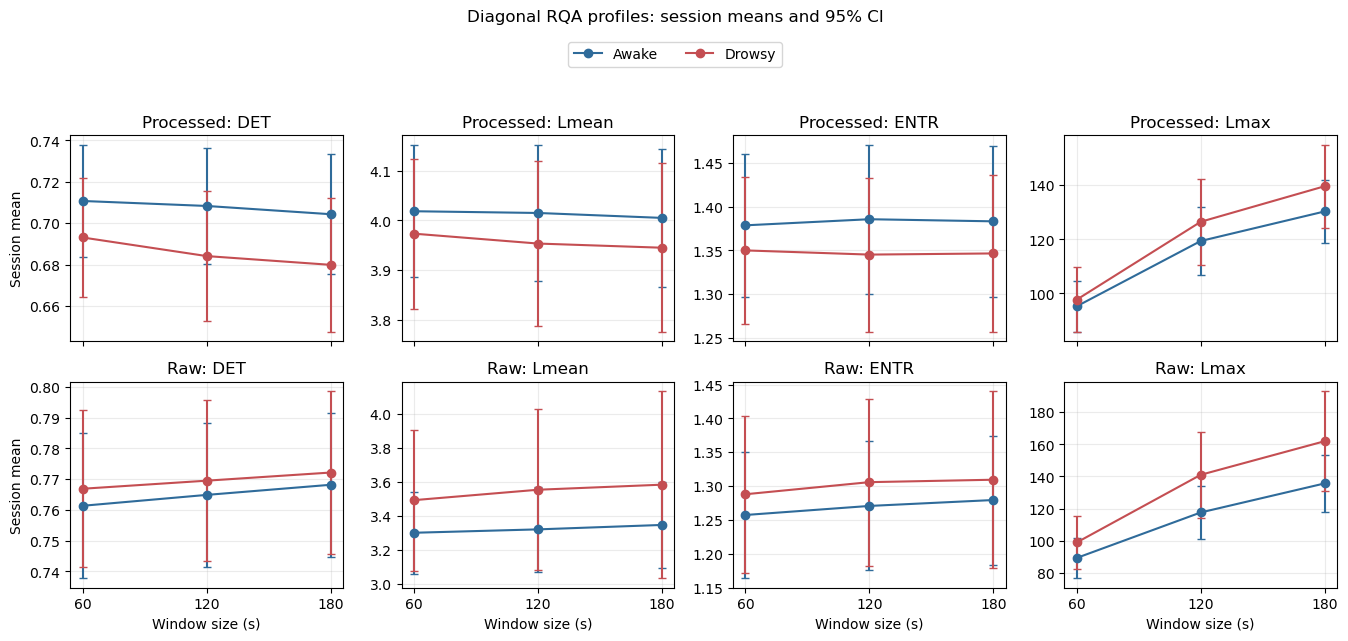

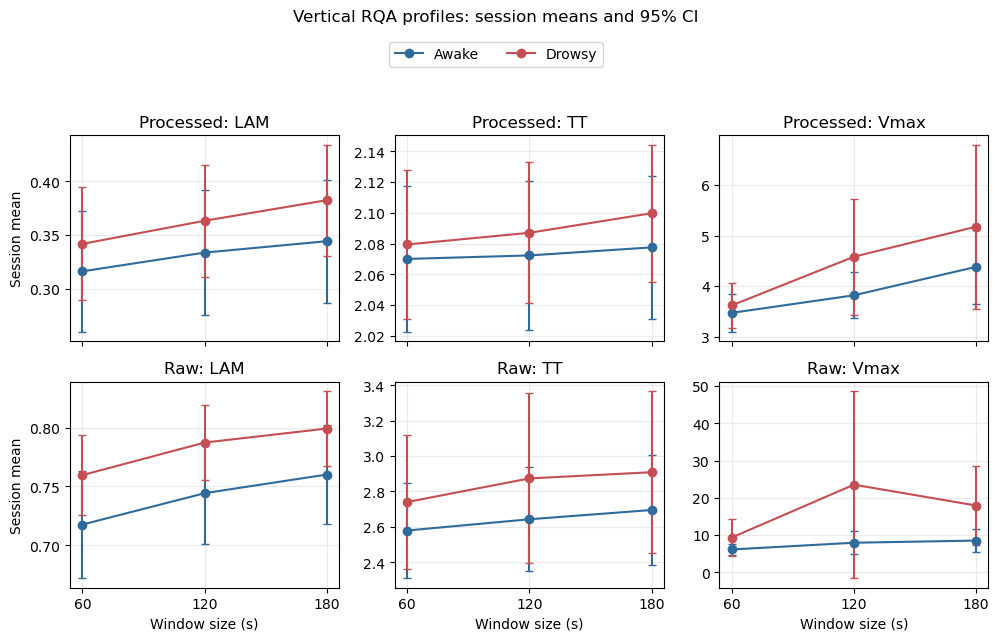

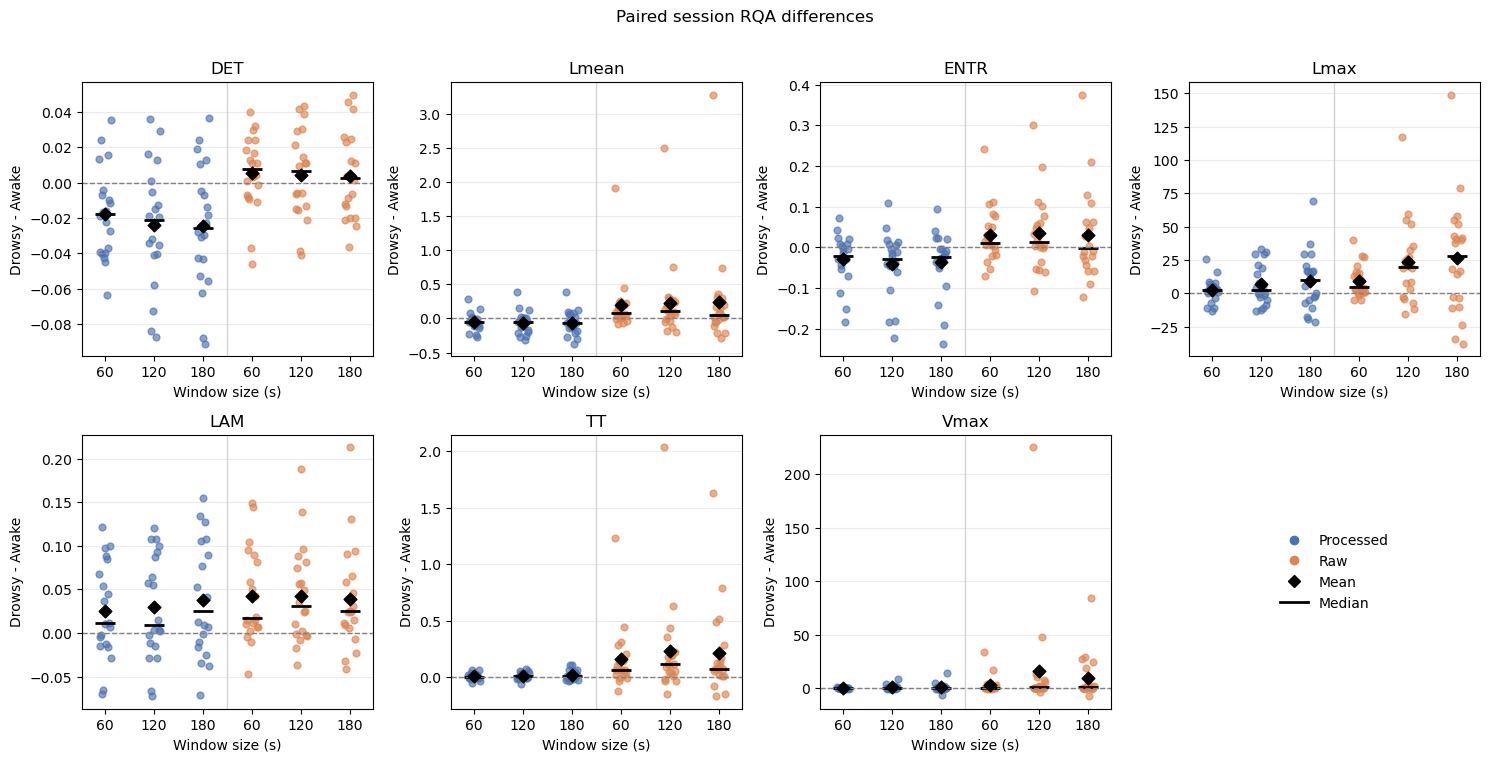

In [8]:
# Cell 8: Publication-ready RQ2 figures
from matplotlib.lines import Line2D

STATE_COLORS = {"Awake": "#2F6B9A", "Drowsy": "#C44E52"}
REPRESENTATION_COLORS = {"Processed": "#4C72B0", "Raw": "#DD8452"}


def plot_state_profiles(metrics, output_path, title):
    """Plot session-mean state profiles with 95% confidence intervals."""
    figure, axes = plt.subplots(
        len(REPRESENTATIONS),
        len(metrics),
        figsize=(3.4 * len(metrics), 6.4),
        squeeze=False,
        sharex=True,
    )
    for row, representation in enumerate(REPRESENTATIONS):
        for column, metric in enumerate(metrics):
            axis = axes[row, column]
            subset = session_summary.loc[
                session_summary["representation"] == representation
            ]
            for state in STATES:
                state_data = subset.loc[subset["state"] == state]
                statistics = (
                    state_data.groupby("window_size")[f"{metric}_mean"]
                    .agg(["mean", "std", "count"])
                    .reindex(WINDOW_SIZES)
                )
                confidence = (
                    1.96
                    * statistics["std"]
                    / np.sqrt(statistics["count"])
                )
                axis.errorbar(
                    WINDOW_SIZES,
                    statistics["mean"],
                    yerr=confidence,
                    marker="o",
                    capsize=3,
                    color=STATE_COLORS[state],
                    label=state,
                )
            axis.set_title(f"{representation}: {metric}")
            axis.set_xticks(WINDOW_SIZES)
            axis.grid(alpha=0.25)
            if row == len(REPRESENTATIONS) - 1:
                axis.set_xlabel("Window size (s)")
            if column == 0:
                axis.set_ylabel("Session mean")

    handles = [
        Line2D(
            [0],
            [0],
            color=STATE_COLORS[state],
            marker="o",
            label=state,
        )
        for state in STATES
    ]
    figure.suptitle(title, y=0.995)
    figure.legend(
        handles=handles,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.955),
        ncol=2,
    )
    figure.tight_layout(rect=(0.0, 0.0, 1.0, 0.90))
    figure.savefig(output_path, dpi=300, bbox_inches="tight")
    return figure


def plot_paired_deltas(output_path):
    """Plot within-session Drowsy-Awake metric differences."""
    figure, axes = plt.subplots(2, 4, figsize=(15, 7.5))
    axes = axes.ravel()
    categories = [
        (representation, window_size)
        for representation in REPRESENTATIONS
        for window_size in WINDOW_SIZES
    ]

    for axis, metric in zip(axes, METRICS):
        for position, (representation, window_size) in enumerate(categories):
            selected = paired_deltas.loc[
                (paired_deltas["representation"] == representation)
                & (paired_deltas["window_size"] == window_size),
                f"delta_{metric}",
            ].dropna()
            jitter = np.linspace(-0.12, 0.12, max(len(selected), 1))
            axis.scatter(
                position + jitter[:len(selected)],
                selected,
                s=24,
                alpha=0.65,
                color=REPRESENTATION_COLORS[representation],
            )
            if not selected.empty:
                axis.scatter(
                    position,
                    selected.mean(),
                    marker="D",
                    s=42,
                    color="black",
                    zorder=3,
                )
                axis.hlines(
                    selected.median(),
                    position - 0.20,
                    position + 0.20,
                    color="black",
                    linewidth=2,
                )
        axis.axhline(0.0, color="gray", linestyle="--", linewidth=1)
        axis.set_title(metric)
        axis.set_xticks(range(len(categories)))
        axis.set_xticklabels(
            [str(item[1]) for item in categories],
        )
        axis.axvline(2.5, color="lightgray", linewidth=1)
        axis.set_xlabel("Window size (s)")
        axis.set_ylabel("Drowsy - Awake")
        axis.grid(axis="y", alpha=0.25)

    axes[-1].axis("off")
    legend = [
        Line2D(
            [0],
            [0],
            marker="o",
            linestyle="none",
            color=REPRESENTATION_COLORS[representation],
            label=representation,
        )
        for representation in REPRESENTATIONS
    ]
    legend.extend(
        [
            Line2D(
                [0],
                [0],
                marker="D",
                linestyle="none",
                color="black",
                label="Mean",
            ),
            Line2D(
                [0],
                [0],
                color="black",
                linewidth=2,
                label="Median",
            ),
        ]
    )
    axes[-1].legend(handles=legend, loc="center", frameon=False)
    figure.suptitle("Paired session RQA differences", y=1.01)
    figure.tight_layout()
    figure.savefig(output_path, dpi=300, bbox_inches="tight")
    return figure


diagonal_figure = plot_state_profiles(
    ("DET", "Lmean", "ENTR", "Lmax"),
    RESULTS_DIR / "fig_rqa_diagonal_rq2.png",
    "Diagonal RQA profiles: session means and 95% CI",
)
vertical_figure = plot_state_profiles(
    ("LAM", "TT", "Vmax"),
    RESULTS_DIR / "fig_rqa_vertical_rq2.png",
    "Vertical RQA profiles: session means and 95% CI",
)
delta_figure = plot_paired_deltas(
    RESULTS_DIR / "fig_rqa_paired_deltas_rq2.png"
)


In [9]:
# Cell 9: Final run summary
window_results = pd.read_csv(WINDOW_OUTPUT)
qc_summary = pd.read_csv(QC_OUTPUT)
paired_deltas = pd.read_csv(DELTA_OUTPUT)
rq2_summary = pd.read_csv(RQ2_OUTPUT)

run_status = pd.DataFrame(
    {
        "item": [
            "Total windows processed",
            "Processed windows",
            "Raw windows",
            "Invalid outputs",
            "Max achieved-RR error",
            "Zero diagonal support",
            "Zero vertical support",
        ],
        "value": [
            len(window_results),
            (window_results["representation"] == "Processed").sum(),
            (window_results["representation"] == "Raw").sum(),
            qc_summary["invalid_outputs"].sum(),
            qc_summary["max_rr_error"].max(),
            qc_summary["zero_diagonal_support"].sum(),
            qc_summary["zero_vertical_support"].sum(),
        ],
    }
)
paired_status = (
    paired_deltas.groupby(
        ["representation", "window_size"],
        observed=True,
    )["session"]
    .nunique()
    .rename("n_paired_sessions")
    .reset_index()
)

display(run_status)
display(paired_status)
display(rq2_summary)


,item,value
0,Total windows processed,3181.000000
1,Processed windows,1544.000000
2,Raw windows,1637.000000
3,Invalid outputs,0.000000
4,Max achieved-RR error,0.000003
5,Zero diagonal support,0.000000
6,Zero vertical support,0.000000


,representation,window_size,n_paired_sessions
0,Processed,60,20
1,Processed,120,20
2,Processed,180,20
3,Raw,60,20
4,Raw,120,20
5,Raw,180,20


,representation,window_size,metric,n_paired_sessions,mean_delta,std_delta,median_delta,q25_delta,q75_delta,n_delta_positive,fraction_delta_positive,min_delta,max_delta
0,Processed,60,DET,20,-0.017596,0.025648,-0.017633,-0.039160,-0.006310,4,0.20,-0.063879,0.035565
1,Processed,60,ENTR,20,-0.028736,0.062453,-0.020828,-0.044830,0.007644,7,0.35,-0.183220,0.072609
2,Processed,60,LAM,20,0.025538,0.055098,0.011393,-0.013088,0.071794,12,0.60,-0.069166,0.121901
3,Processed,60,Lmax,20,2.456423,9.109597,2.874172,-0.415463,6.151716,15,0.75,-13.506667,25.607143
4,Processed,60,Lmean,20,-0.045135,0.129765,-0.046670,-0.105685,0.001576,5,0.25,-0.279045,0.289376
5,Processed,60,TT,20,0.009418,0.027491,0.006216,-0.004087,0.019811,13,0.65,-0.049703,0.065178
6,Processed,60,Vmax,20,0.147043,0.477055,0.051667,-0.202971,0.410556,11,0.55,-0.535714,1.386905
7,Processed,120,DET,20,-0.024155,0.034507,-0.021227,-0.040734,-0.003723,5,0.25,-0.087171,0.036107
8,Processed,120,ENTR,20,-0.040513,0.080387,-0.029068,-0.050229,0.005953,6,0.30,-0.223714,0.109955
9,Processed,120,LAM,20,0.029614,0.060248,0.009144,-0.012592,0.089137,13,0.65,-0.072337,0.120480


# Tổng hợp kết quả RQA toàn bộ dataset

Kết quả dưới đây là mô tả RQA theo đơn vị session. Không có kiểm định suy
luận và windows không được xem là các quan sát độc lập.

## 1. Phạm vi và protocol

- Số session: **20**.
- Tổng số windows: **3,181**.
- Processed: **1,544** windows; Raw: **1,637**
  windows.
- Mỗi tổ hợp `representation × window size` có **20 paired
  sessions**.
- Fixed RR = **2%**, `m = 8`, `l_min = v_min = 2`.
- `tau_processed = 0.16 s`, `tau_raw = 0.20 s`.
- Raw dùng SQI-only và không lọc stationarity; Processed dùng SQI và
  Processed stationarity.

## 2. Full-dataset QC

| Chỉ tiêu | Kết quả |
|---|---:|
| Invalid outputs | 0 |
| Maximum absolute RR error | 3.230e-06 |
| Zero diagonal support | 0 |
| Zero vertical support | 0 |
| Full QC | PASS |

Fixed-RR giữ recurrence density tương đương giữa Raw và Processed theo
thiết kế. Không có window bị loại khỏi phân tích do thiếu diagonal hoặc
vertical line support.

## 3. Mean paired delta theo session

Quy ước: `delta = Drowsy - Awake`. Giá trị dương nghĩa là metric trung
bình cao hơn ở Drowsy; giá trị âm nghĩa là metric trung bình thấp hơn.

| Representation | Window | DET | Lmean | ENTR | Lmax | LAM | TT | Vmax |
|---|---:|---:|---:|---:|---:|---:|---:|---:|
| Processed | 60 s | -0.0176 | -0.0451 | -0.0287 | 2.4564 | 0.0255 | 0.0094 | 0.1470 |
| Processed | 120 s | -0.0242 | -0.0615 | -0.0405 | 7.0999 | 0.0296 | 0.0147 | 0.7637 |
| Processed | 180 s | -0.0244 | -0.0600 | -0.0368 | 9.3179 | 0.0382 | 0.0222 | 0.7950 |
| Raw | 60 s | 0.0055 | 0.1924 | 0.0307 | 9.6051 | 0.0420 | 0.1609 | 3.2115 |
| Raw | 120 s | 0.0046 | 0.2338 | 0.0351 | 23.3605 | 0.0430 | 0.2309 | 15.5938 |
| Raw | 180 s | 0.0040 | 0.2375 | 0.0300 | 26.1965 | 0.0391 | 0.2136 | 9.4099 |

## 4. Tính nhất quán về dấu

Bảng dưới là tỷ lệ session có `delta > 0`.

| Representation | Window | DET | Lmean | ENTR | Lmax | LAM | TT | Vmax |
|---|---:|---:|---:|---:|---:|---:|---:|---:|
| Processed | 60 s | 0.20 | 0.25 | 0.35 | 0.75 | 0.60 | 0.65 | 0.55 |
| Processed | 120 s | 0.25 | 0.35 | 0.30 | 0.60 | 0.65 | 0.60 | 0.60 |
| Processed | 180 s | 0.25 | 0.35 | 0.25 | 0.60 | 0.65 | 0.65 | 0.60 |
| Raw | 60 s | 0.65 | 0.75 | 0.70 | 0.85 | 0.85 | 0.80 | 0.85 |
| Raw | 120 s | 0.55 | 0.70 | 0.65 | 0.75 | 0.70 | 0.80 | 0.75 |
| Raw | 180 s | 0.55 | 0.65 | 0.50 | 0.65 | 0.80 | 0.85 | 0.65 |

## 5. Mô tả kết quả quan trọng

- Với **Processed**, mean delta của `DET`, `Lmean` và `ENTR` âm tại cả
  60, 120 và 180 s. Mean delta của `Lmax`, `LAM`, `TT` và `Vmax` dương
  tại cả ba window sizes.
- Với **Raw**, mean delta của cả bảy metrics dương tại cả ba window
  sizes. Mức tăng lớn nhất về trị tuyệt đối xuất hiện ở các metric phụ
  thuộc line cực đại, đặc biệt `Lmax` và `Vmax`.
- `LAM` có mean delta dương ở cả Raw và Processed tại mọi window size.
  Tỷ lệ session có delta dương nằm trong khoảng 0.60–0.65 với Processed
  và 0.70–0.85 với Raw.
- Processed và Raw thể hiện hướng khác nhau đối với nhóm `DET`, `Lmean`
  và `ENTR`: Processed có mean delta âm, trong khi Raw có mean delta
  dương. Đây là mô tả khác biệt theo representation, không phải kết quả
  kiểm định thống kê.
- Các kết quả trên là descriptive evidence cho RQ2 ở cấp session. Việc
  đánh giá statistical significance cần được thực hiện ở bước phân tích
  suy luận riêng.

## 6. Output đã lưu

- `rqa_window_level.csv`
- `rqa_qc_summary.csv`
- `rqa_session_state_summary.csv`
- `rqa_session_paired_deltas.csv`
- `rqa_rq2_summary.csv`
- `fig_rqa_diagonal_rq2.png`
- `fig_rqa_vertical_rq2.png`
- `fig_rqa_paired_deltas_rq2.png`
